In [ ]:
import pandas as pd



Epoch 1/50


/Users/artyomk/dev/projects/market-mind/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.9997
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9950
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9944
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9941
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9910
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9908
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9907
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9909
Epoch 9/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9892
Epoch 10/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9845
Epoch 11/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9868
Epoch 12/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9768
Epoch 13/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9761
Epoch 14/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.9714
Epoch 15/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step 

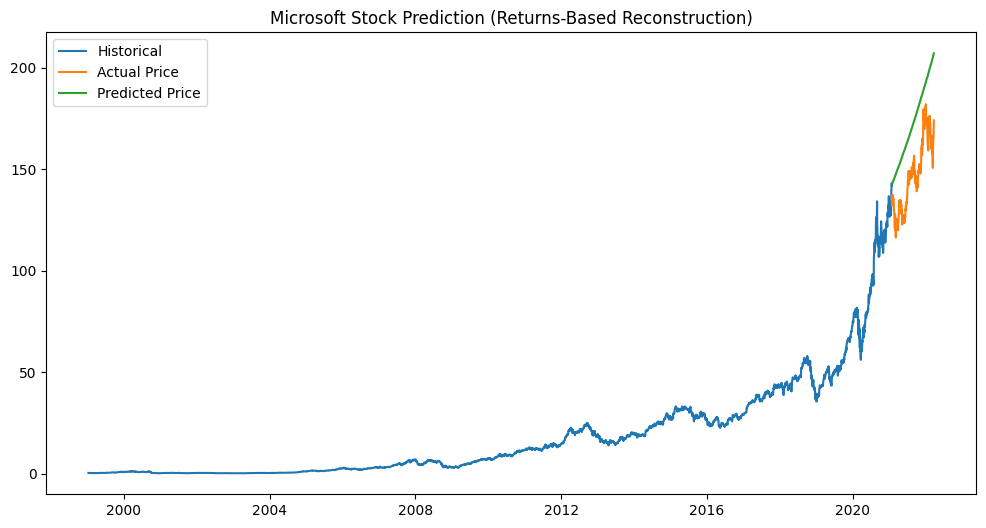

RMSE:  27.571236653348738
NRMSE(range):  0.41997317857102523
NRMSE(mean):  0.18803626981367147


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

# All inputs needed for model: date, close price pairs of stock data

# ==========================================
# 1. DATA LOADING & FEATURE ENGINEERING
# ==========================================
data = pd.read_csv("AppleStock.csv")
data['date'] = pd.to_datetime(data['date'])

# Using % change (Returns) to make data stationary (prevents trend-following overfitting)
data['return'] = data['close'].pct_change()

# IMPROVEMENT: Add a 5-day Moving Average of returns to give the model "momentum" context
data['return_mavg'] = data['return'].rolling(window=5).mean()

# Drop rows with NaN values created by pct_change and rolling mean
data = data.dropna().reset_index(drop=True)

# We use two features: the raw return and the moving average return
feature_cols = ['return', 'return_mavg']
dataset = data[feature_cols].values

# ==========================================
# 2. DATA SPLITTING & SCALING
# ==========================================
training_data_len = int(np.ceil(len(dataset)) * 0.95)

# Scaler is fitted ONLY on training data to avoid data leakage from the future
scaler = StandardScaler()
scaler.fit(dataset[:training_data_len])

scaled_train = scaler.transform(dataset[:training_data_len])
# For testing, we need the 60 days prior to the test start for the first window
scaled_test_source = scaler.transform(dataset[training_data_len - 60:])

# ==========================================
# 3. SLIDING WINDOW PREPARATION
# ==========================================
X_train, y_train = [], []

for i in range(60, len(scaled_train)):
    X_train.append(scaled_train[i-60:i, :]) # Take all features (return + mavg)
    y_train.append(scaled_train[i, 0])      # Predict only the 'return' (index 0)

X_train, y_train = np.array(X_train), np.array(y_train)

# ==========================================
# 4. MODEL ARCHITECTURE & REGULARIZATION
# ==========================================
model = keras.models.Sequential([
    keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    keras.layers.Dropout(0.3), # Dropout helps prevent overfitting to noise
    keras.layers.LSTM(64, return_sequences=False),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1) 
])

# IMPROVEMENT: Early Stopping halts training if the model stops improving
early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

model.compile(optimizer="adam", loss="mse")
model.fit(X_train, y_train, epochs=50, batch_size=32, callbacks=[early_stop], verbose=1)

# ==========================================
# 5. RECURSIVE PREDICTION LOOP
# ==========================================
current_batch = scaled_test_source[:60].reshape((1, 60, len(feature_cols)))
predicted_returns_scaled = []

# Forecast loop
for i in range(len(scaled_test_source) - 60):
    # Predict the next day's scaled return
    pred_scaled = model.predict(current_batch, verbose=0)[0]
    predicted_returns_scaled.append(pred_scaled)
    
    # Update context: In a real recursive loop with multiple features, 
    # we'd usually just use 1 feature or update the MAVG manually.
    # For simplicity here, we append the prediction and a dummy MAVG value (0)
    new_row = np.array([[pred_scaled[0], 0]]) 
    current_batch = np.append(current_batch[:, 1:, :], [new_row], axis=1)
    
# Inverse transform to get actual % change values
# (We create a dummy array to match the scaler's expected 2-column input)
dummy_scaler = np.zeros((len(predicted_returns_scaled), 2))
dummy_scaler[:, 0] = np.array(predicted_returns_scaled).flatten()
predictions_raw_returns = scaler.inverse_transform(dummy_scaler)[:, 0]

# ==========================================
# 6. PRICE RECONSTRUCTION & VISUALIZATION
# ==========================================
# Logic: Price_t = Price_{t-1} * (1 + Return_t)
last_actual_price = data['close'].iloc[training_data_len - 1]
reconstructed_prices = []

for ret in predictions_raw_returns:
    next_price = last_actual_price * (1 + ret)
    reconstructed_prices.append(next_price)
    last_actual_price = next_price # Loop uses predicted price for the next step

# Setup Plotting Data
train_df = data[:training_data_len]
test_df = data[training_data_len:].copy()
test_df['Predictions'] = reconstructed_prices

plt.figure(figsize=(12,6))
plt.plot(train_df['date'], train_df['close'], label="Historical")
plt.plot(test_df['date'], test_df['close'], label="Actual Price")
plt.plot(test_df['date'], test_df['Predictions'], label="Predicted Price")
plt.title("Apple Stock Prediction")
plt.legend()
plt.show()

rmse = np.sqrt(np.mean((test_df['close'] - test_df['Predictions']) ** 2))

price_range = test_df['close'].max() - test_df['close'].min()
nrmse_range = rmse / price_range

price_mean = test_df['close'].mean()
nrmse_mean = rmse / price_mean

print("RMSE: ", rmse)
print("NRMSE(range): ", nrmse_range)
print("NRMSE(mean): ", nrmse_mean)